# KNN


In [1]:
# Cell 1: Import thư viện, khai báo đường dẫn dataset và các tham số chung.
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

DATASET_DIR = Path(r"C:\Users\dungt\Downloads\BCKLTN\dataset_classification")

CLASS_NAMES = ["bad", "good", "shell"]
IMG_SIZE = (224, 224)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
RANDOM_STATE = 42
N_TEST_IMAGES = 12

FEATURE_TYPE = "color_hog"
COLOR_HIST_BINS = 16
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

In [2]:
# Cell 2: Đọc ảnh, trích đặc trưng, tải dữ liệu, đánh giá model và hiển thị ảnh test.
def read_image(path):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    return np.array(img)

def extract_features(img_rgb):
    features = []

    if FEATURE_TYPE in ["histogram", "color_hog"]:
        hsv = rgb2hsv(img_rgb / 255.0)
        hist_features = []
        for ch in range(3):
            hist, _ = np.histogram(
                hsv[:, :, ch],
                bins=COLOR_HIST_BINS,
                range=(0, 1),
                density=True
            )
            hist_features.extend(hist)
        features.extend(hist_features)

    if FEATURE_TYPE in ["hog", "color_hog"]:
        gray = rgb2gray(img_rgb / 255.0)
        hog_features = hog(
            gray,
            orientations=HOG_ORIENTATIONS,
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            block_norm="L2-Hys",
            feature_vector=True
        )
        features.extend(hog_features)

    return np.array(features, dtype=np.float32)

def load_split(split_name):
    X, y, paths = [], [], []
    split_dir = DATASET_DIR / split_name

    if not split_dir.exists():
        raise FileNotFoundError(f"Không tìm thấy thư mục: {split_dir}")

    for class_id, class_name in enumerate(CLASS_NAMES):
        class_dir = split_dir / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Không tìm thấy thư mục lớp: {class_dir}")

        for path in sorted(class_dir.rglob("*")):
            if path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            try:
                img = read_image(path)
                X.append(extract_features(img))
                y.append(class_id)
                paths.append(path)
            except (UnidentifiedImageError, OSError):
                pass

    return np.array(X), np.array(y), paths

def evaluate_model(model, X, y, split_name):
    y_pred = model.predict(X)

    precision = precision_score(y, y_pred, average="macro", zero_division=0)
    recall = recall_score(y, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y, y_pred, average="macro", zero_division=0)

    print(f"\n{split_name.upper()} METRICS")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")

    print("\nClassification report:")
    print(classification_report(
        y,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(y, y_pred, labels=list(range(len(CLASS_NAMES))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"Confusion Matrix - {split_name}")
    plt.show()

    report_df = pd.DataFrame(classification_report(
        y,
        y_pred,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )).transpose()

    return y_pred, report_df, cm

def show_test_images(model, test_paths, y_true, n_images=N_TEST_IMAGES):
    if len(test_paths) == 0:
        print("Không có ảnh test để hiển thị.")
        return

    n_images = min(n_images, len(test_paths))
    idxs = random.sample(range(len(test_paths)), n_images)

    cols = 4
    rows = int(np.ceil(n_images / cols))
    plt.figure(figsize=(cols * 4, rows * 4))

    for plot_idx, idx in enumerate(idxs, 1):
        path = test_paths[idx]
        img = read_image(path)
        feature = extract_features(img).reshape(1, -1)
        pred = model.predict(feature)[0]

        plt.subplot(rows, cols, plot_idx)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[pred]}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

In [3]:
# Cell 3: Tải dữ liệu train/val/test và thống kê số lượng ảnh từng lớp.
print("Dataset:", DATASET_DIR)

X_train, y_train, train_paths = load_split("train")
X_val, y_val, val_paths = load_split("val")
X_test, y_test, test_paths = load_split("test")

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

for split_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = pd.Series(y).value_counts().sort_index()
    print(f"\n{split_name.upper()}:")
    for class_id, class_name in enumerate(CLASS_NAMES):
        print(f"{class_name}: {counts.get(class_id, 0)}")

Dataset: C:\Users\dungt\Downloads\BCKLTN\dataset_classification
Train: (6110, 6132) (6110,)
Val:   (2990, 6132) (2990,)
Test:  (1886, 6132) (1886,)

TRAIN:
bad: 1792
good: 2712
shell: 1606

VAL:
bad: 816
good: 1551
shell: 623

TEST:
bad: 579
good: 632
shell: 675


In [4]:
# Cell 4: Khởi tạo và huấn luyện mô hình.
from sklearn.neighbors import KNeighborsClassifier

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="minkowski",
        p=2
    ))
])

model.fit(X_train, y_train)
print("Đã huấn luyện xong KNN.")

Đã huấn luyện xong KNN.



TEST METRICS
Precision (macro): 0.7353
Recall (macro):    0.7118
F1-score (macro):  0.6936

Classification report:
              precision    recall  f1-score   support

         bad     0.5847    0.9119    0.7126       579
        good     0.7735    0.4161    0.5412       632
       shell     0.8476    0.8074    0.8270       675

    accuracy                         0.7084      1886
   macro avg     0.7353    0.7118    0.6936      1886
weighted avg     0.7421    0.7084    0.6961      1886



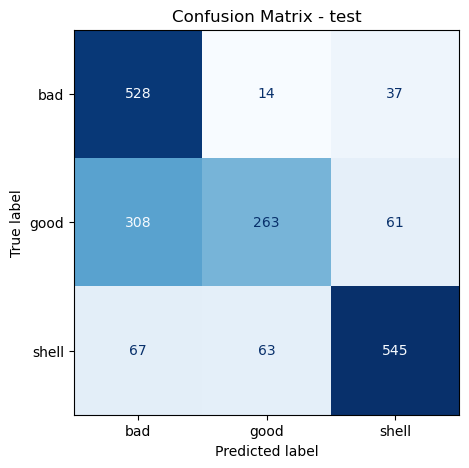

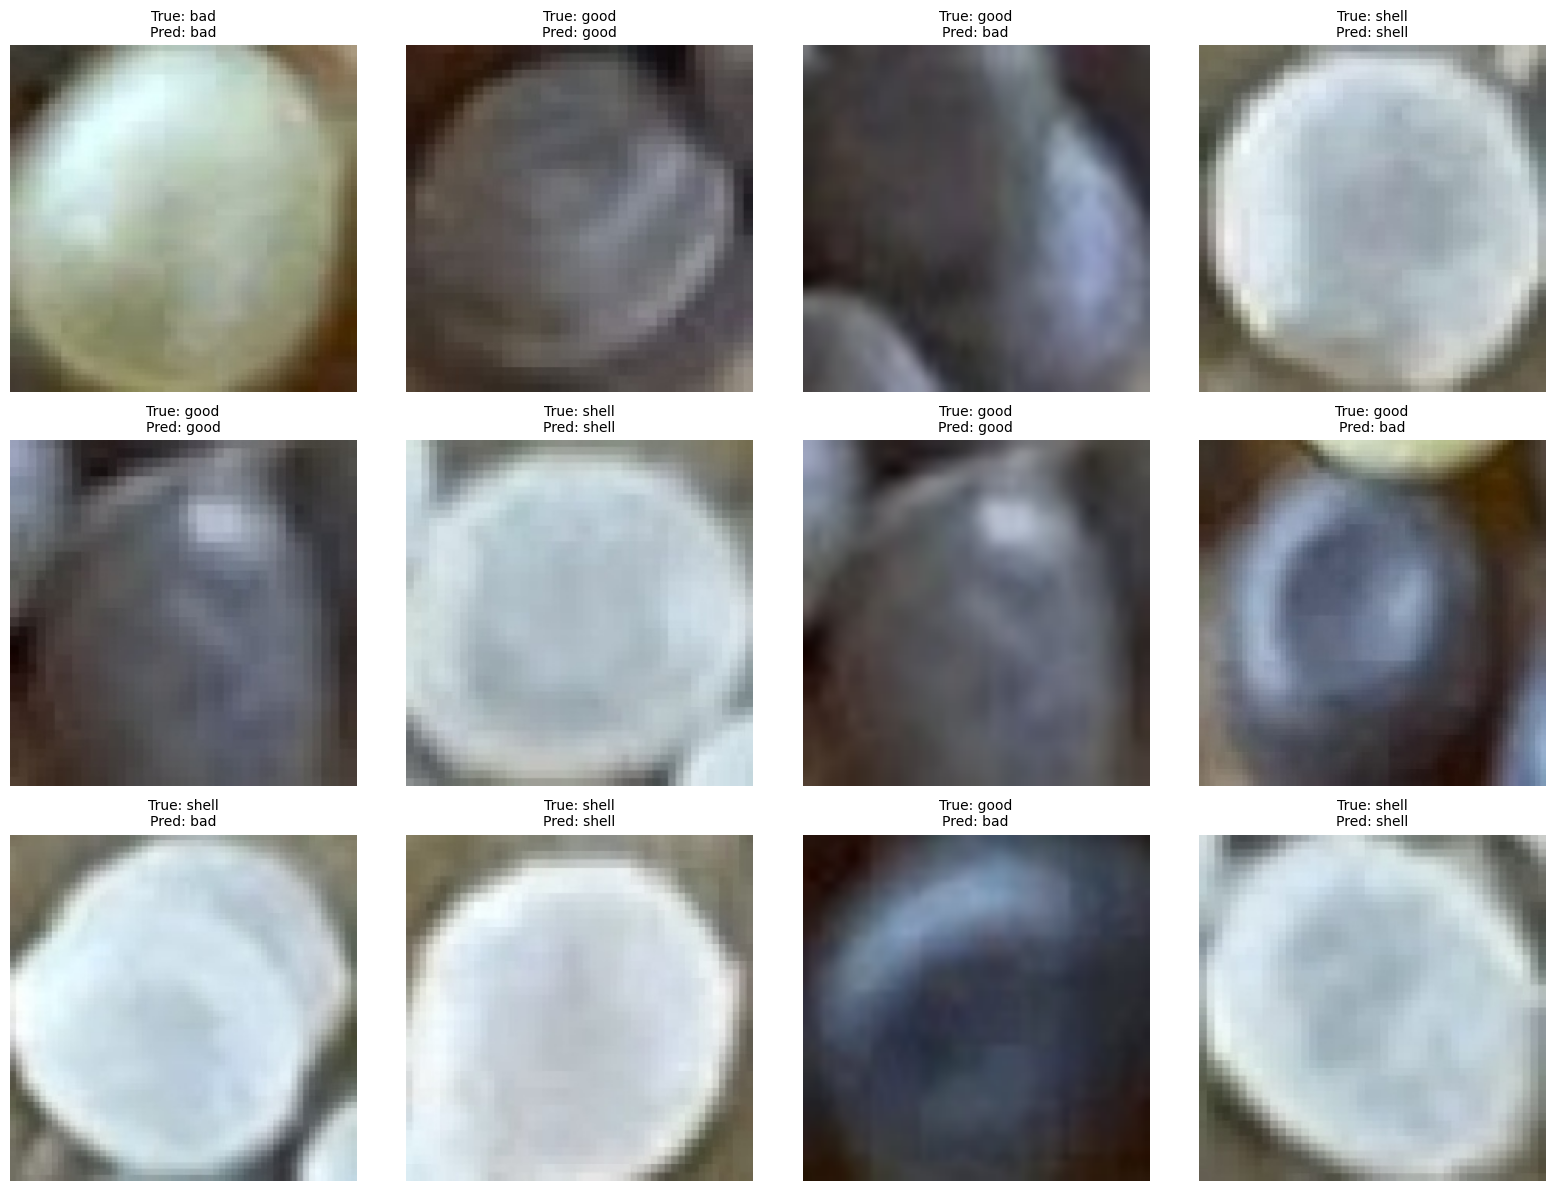

Đã lưu kết quả vào: outputs_knn


In [5]:
# Cell 5: Đánh giá trên tập test, hiển thị ảnh test và lưu kết quả.
y_pred_test, report_df, cm = evaluate_model(model, X_test, y_test, "test")
show_test_images(model, test_paths, y_test)

output_dir = Path("outputs_knn")
output_dir.mkdir(exist_ok=True)

report_df.to_csv(output_dir / "knn_classification_report.csv", encoding="utf-8-sig")
joblib.dump(model, output_dir / "knn_model.pkl")

print("Đã lưu kết quả vào:", output_dir)